<a href="https://colab.research.google.com/github/MKorp7/KuaiRec---Reccomender-System/blob/main/Recommender_System_KuaiRec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KuaiRec

KuaiRec is a real-world dataset collected from the video-sharing mobile app Kuaishou. What makes it unique is that it is *fully observed*: the small interaction matrix has near-complete coverage, meaning almost every user has watched almost every video. This is extremely rare in real-world recommendation datasets, where interaction matrices are typically very sparse.

## Dataset used - details

This project use data shared under CC-BY-4.0 license. All rigths belongs to authors of KuaiRec dataset (Gao, Chongming and Li, Shijun and Lei, Wenqiang and Chen, Jiawei and Li, Biao and Jiang, Peng and He, Xiangnan and Mao, Jiaxin and Chua, Tat-Seng).

The detailed description of data can be found here: https://arxiv.org/abs/2202.10842 and at GitHub https://github.com/chongminggao/KuaiRec/


## Goal of this project
* Exploring the dataset
* Build and compare diffrent recomendation models



In [ ]:
import os, glob, json, math, random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy import sparse
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer


import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 1. Data

In [ ]:
DATA_DIR = "/content/kuairec"
os.makedirs(DATA_DIR, exist_ok=True)
os.chdir(DATA_DIR)

!wget -q --show-progress https://zenodo.org/records/18164998/files/KuaiRec.zip -O KuaiRec.zip
!unzip -q -o KuaiRec.zip

KuaiRec.zip         100%[===================>] 411.95M  20.1MB/s    in 24s     


In [ ]:
!ls

'KuaiRec 2.0'   KuaiRec.zip


In [ ]:
# Some of this files are pretty big, please make sure that you have enough RAM
big_df = pd.read_csv(os.path.join(DATA_DIR, "KuaiRec 2.0/data", "big_matrix.csv"))
small_df = pd.read_csv(os.path.join(DATA_DIR, "KuaiRec 2.0/data", "small_matrix.csv"))
item_df = pd.read_csv(os.path.join(DATA_DIR, "KuaiRec 2.0/data", "item_daily_features.csv"))
user_df = pd.read_csv(os.path.join(DATA_DIR, "KuaiRec 2.0/data", "user_features.csv"))
social_network = pd.read_csv(os.path.join(DATA_DIR, "KuaiRec 2.0/data", "social_network.csv"))
social_network["friend_list"] = social_network["friend_list"].map(eval)
item_categories = pd.read_csv(os.path.join(DATA_DIR, "KuaiRec 2.0/data", "item_categories.csv"))
item_categories["feat"] = item_categories["feat"].map(eval)





In [ ]:
for df in [big_df, small_df]:
    df["time"] = pd.to_datetime(df["time"])
    df["hour"] = df["time"].dt.hour

In [ ]:
print("Small matrix")
small_df.head()

Small matrix


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,hour
0,14,148,4381,6067,2020-07-05 05:27:48.378,20200705.0,1.593898e+09,0.722103,5.0
1,14,183,11635,6100,2020-07-05 05:28:00.057,20200705.0,1.593898e+09,1.907377,5.0
2,14,3649,22422,10867,2020-07-05 05:29:09.479,20200705.0,1.593898e+09,2.063311,5.0
3,14,5262,4479,7908,2020-07-05 05:30:43.285,20200705.0,1.593898e+09,0.566388,5.0
4,14,8234,4602,11000,2020-07-05 05:35:43.459,20200705.0,1.593899e+09,0.418364,5.0


In [ ]:
print("Big matrix")
big_df.head()

Big matrix


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,hour
0,0,3649,13838,10867,2020-07-05 00:08:23.438,20200705,1.593879e+09,1.273397,0
1,0,9598,13665,10984,2020-07-05 00:13:41.297,20200705,1.593879e+09,1.244082,0
2,0,5262,851,7908,2020-07-05 00:16:06.687,20200705,1.593879e+09,0.107613,0
3,0,1963,862,9590,2020-07-05 00:20:26.792,20200705,1.593880e+09,0.089885,0
4,0,8234,858,11000,2020-07-05 00:43:05.128,20200705,1.593881e+09,0.078000,0


## 2. Exploratory Data Analysis


In [ ]:
print("Number of users:", len(big_df["user_id"].unique()))
print("Number of videos:", len(big_df["video_id"].unique()))
print("Number of interactions:", len(big_df))

Number of users: 7176
Number of videos: 10728
Number of interactions: 12530806


In [ ]:
print("Sparcity")
print("Big matrix:", 1 - len(big_df) / (len(big_df["user_id"].unique()) * len(big_df["video_id"].unique())))
print("Small matrix:", 1 - len(small_df) / (len(small_df["user_id"].unique()) * len(small_df["video_id"].unique())))

Sparcity
Big matrix: 0.8372287077149201
Small matrix: 0.0037975058351477076



Mean:   0.945
Median: 0.723
Std:    1.675

WR <= 0.1:     8.9%
WR (0.1, 0.5]: 27.0%
WR (0.5, 1]:   30.3%
WR > 1:        33.8%



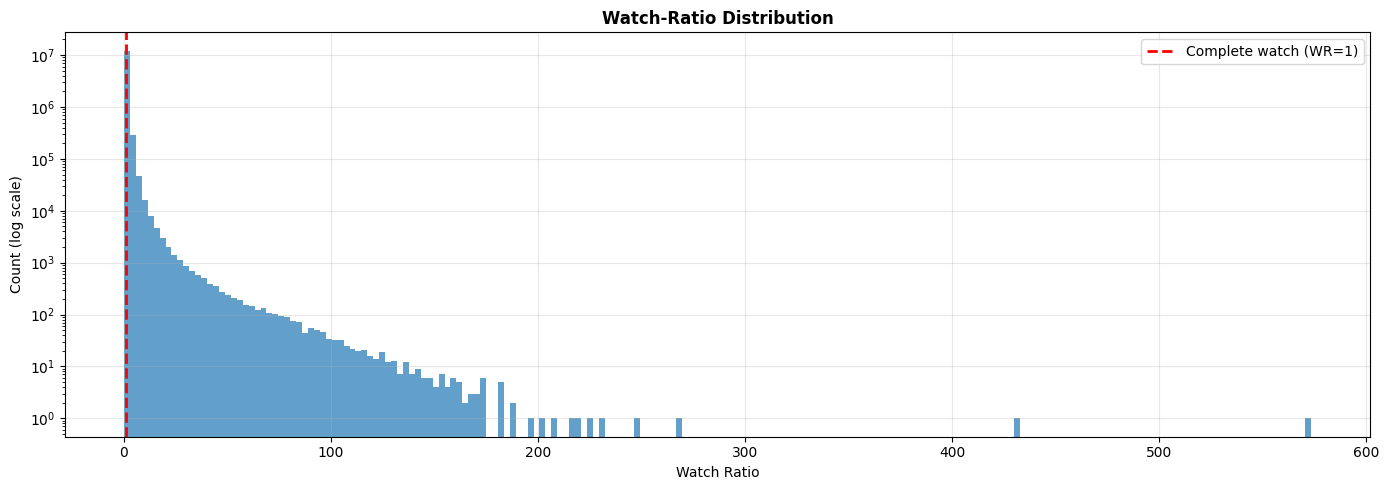

In [ ]:
wr = big_df["watch_ratio"].dropna()

stats_text = f"""
Mean:   {wr.mean():.3f}
Median: {wr.median():.3f}
Std:    {wr.std():.3f}

WR <= 0.1:     {(wr <= 0.1).mean():.1%}
WR (0.1, 0.5]: {((wr > 0.1) & (wr <= 0.5)).mean():.1%}
WR (0.5, 1]:   {((wr > 0.5) & (wr <= 1.0)).mean():.1%}
WR > 1:        {(wr > 1.0).mean():.1%}
"""
print(stats_text)

fig, ax = plt.subplots(figsize=(14, 5))

ax.hist(wr, bins=200, alpha=0.7, edgecolor="none")
ax.axvline(1.0, ls="--", lw=2, label="Complete watch (WR=1)", color = "red")

ax.set_xlabel("Watch Ratio")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")

ax.set_title("Watch-Ratio Distribution", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.1 Does engagement vary throughout the day?

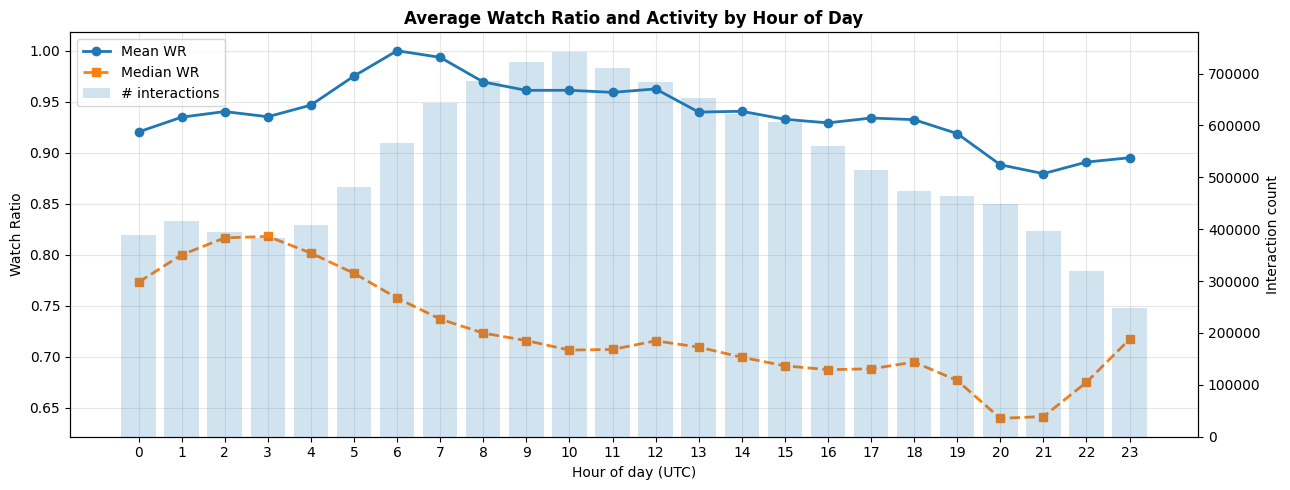

In [ ]:
hourly = (
    big_df.groupby("hour")["watch_ratio"]
    .agg(mean="mean", median="median", count="size")
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(hourly["hour"], hourly["mean"],   "o-", lw=2, label="Mean WR")
ax1.plot(hourly["hour"], hourly["median"], "s--",  lw=2, label="Median WR")
ax2.bar(hourly["hour"], hourly["count"], alpha=0.2, label="# interactions")

ax1.set_xlabel("Hour of day (UTC)")
ax1.set_ylabel("Watch Ratio")
ax2.set_ylabel("Interaction count")
ax1.set_title("Average Watch Ratio and Activity by Hour of Day", fontweight="bold")
ax1.set_xticks(range(24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

the hourly plot suggests a clear time-of-day pattern, and it appears much more strongly in the median than in the mean. This implies the “typical” behavior shifts by hour, while the mean is partially stabilized by a smaller number of outliers. Since timestamps are in UTC and the user base is predominantly in China, time-zone mixing is hopefully limited, so the observed pattern can reasonably be interpreted as a real time-of-day effect rather than an artifact of multiple time zones.


### 2.2 Social graph structure

In [ ]:
social_network["n_friends"] = social_network["friend_list"].map(len)

total_users    = user_df.shape[0]
connected      = (social_network["n_friends"] > 0).sum()
isolated       = total_users - connected
avg_friends    = social_network["n_friends"].mean()
median_friends = social_network["n_friends"].median()

print(f"Total users in dataset  : {total_users:,}")
print(f"Users with ≥1 friend    : {connected:,}  ({connected/total_users:.1%})")
print(f"Users with 0 friends    : {isolated:,}  ({isolated/total_users:.1%})")
print(f"Avg friend count        : {avg_friends:.2f}")
print(f"Median friend count     : {median_friends:.1f}")
print(f"Max friend count        : {social_network['n_friends'].max()}")


Total users in dataset  : 7,176
Users with ≥1 friend    : 472  (6.6%)
Users with 0 friends    : 6,704  (93.4%)
Avg friend count        : 1.42
Median friend count     : 1.0
Max friend count        : 5


Most users have no friends at all in the dataset, and even for those who do, the average friend count is very low. In theory this social graph could enable a more targeted analysis of social influence on watch behavior, but since the subset of users with friend networks is small, I'm not going to pursue that direction here.

### 2.3 Content category distribution

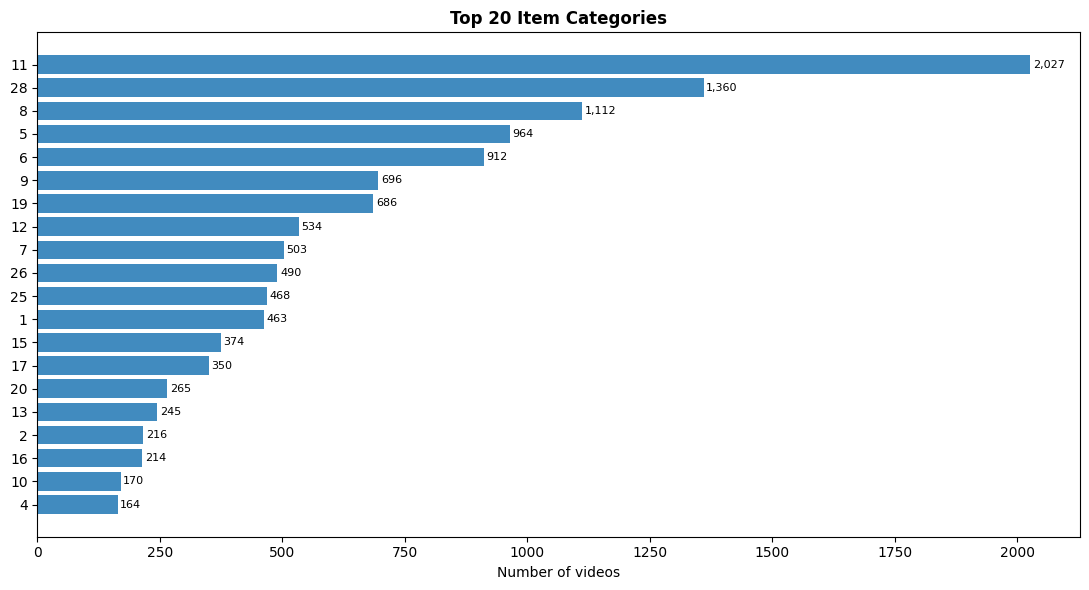

Unique categories in dataset: 31
Avg categories per video    : 1.18


In [ ]:
from collections import Counter

all_cats = [cat for cats in item_categories["feat"] for cat in cats]
cat_counts = Counter(all_cats)

top_n = 20
top_cats = pd.DataFrame(cat_counts.most_common(top_n), columns=["category", "count"])

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_cats["category"].astype(str)[::-1],
               top_cats["count"][::-1],
               alpha=0.85)
ax.set_xlabel("Number of videos")
ax.set_title(f"Top {top_n} Item Categories", fontweight="bold")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 5, bar.get_y() + bar.get_height()/2, f"{w:,}",
            va="center", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Unique categories in dataset: {len(cat_counts)}")
print(f"Avg categories per video    : {item_categories['feat'].map(len).mean():.2f}")


### 2.4 Video duration distribution

Video duration (seconds):
    Min: 0.14s
    p10: 6.07s
    p25: 7.43s
    p50: 9.64s
    p75: 12.18s
    p90: 24.24s
    p99: 133.10s
    Max: 315.07s
   Mean: 14.62s

Unique videos per duration tier (out of 10,728 total):
  < 10s: 6,041  (56.3%)
  10–20s: 3,605  (33.6%)
  20–30s: 464  (4.3%)
  30–60s: 458  (4.3%)
  > 60s: 160  (1.5%)


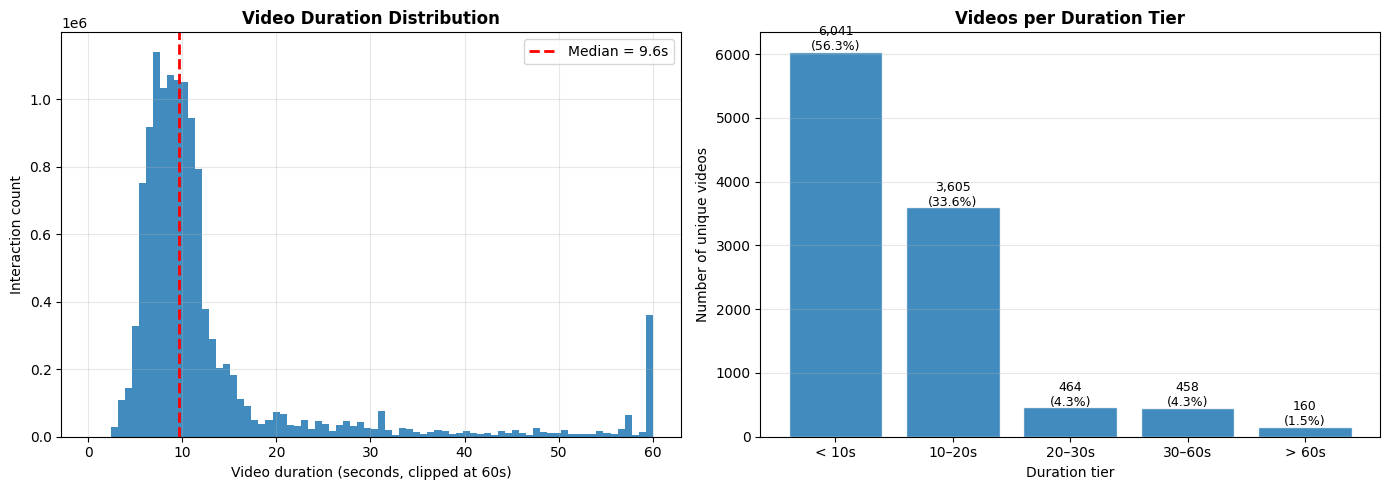

In [ ]:
# video_duration is in milliseconds — convert to seconds for readability
dur_s = big_df["video_duration"].dropna() / 1000

dur_stats = {
    "Min":  dur_s.min(),
    "p10":  dur_s.quantile(0.10),
    "p25":  dur_s.quantile(0.25),
    "p50":  dur_s.median(),
    "p75":  dur_s.quantile(0.75),
    "p90":  dur_s.quantile(0.90),
    "p99":  dur_s.quantile(0.99),
    "Max":  dur_s.max(),
    "Mean": dur_s.mean(),
}
print("Video duration (seconds):")
for k, v in dur_stats.items():
    print(f"  {k:>5}: {v:.2f}s")

# Bucket into rough length tiers
def dur_bucket(s):
    if s < 10:   return "< 10s"
    if s < 20:   return "10–20s"
    if s < 30:   return "20–30s"
    if s < 60:   return "30–60s"
    return "> 60s"

bucket_order = ["< 10s", "10–20s", "20–30s", "30–60s", "> 60s"]
buckets = dur_s.apply(dur_bucket).value_counts().reindex(bucket_order, fill_value=0)
total_vids = big_df["video_id"].nunique()
print(f"\nUnique videos per duration tier (out of {total_vids:,} total):")
vid_buckets = (
    big_df[["video_id", "video_duration"]].drop_duplicates("video_id")
    .assign(dur_s=lambda d: d["video_duration"] / 1000)
    .assign(tier=lambda d: d["dur_s"].apply(dur_bucket))
    ["tier"].value_counts().reindex(bucket_order, fill_value=0)
)
for tier, cnt in vid_buckets.items():
    print(f"  {tier}: {cnt:,}  ({cnt/total_vids:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dur_s.clip(upper=60), bins=80, alpha=0.85, edgecolor="none")
axes[0].axvline(dur_s.median(), ls="--", lw=2, color="red", label=f"Median = {dur_s.median():.1f}s")
axes[0].set_xlabel("Video duration (seconds, clipped at 60s)")
axes[0].set_ylabel("Interaction count")
axes[0].set_title("Video Duration Distribution", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(bucket_order, vid_buckets.values, alpha=0.85, edgecolor="white")
axes[1].set_xlabel("Duration tier")
axes[1].set_ylabel("Number of unique videos")
axes[1].set_title("Videos per Duration Tier", fontweight="bold")
for i, (tier, v) in enumerate(vid_buckets.items()):
    axes[1].text(i, v + 20, f"{v:,}\n({v/total_vids:.1%})", ha="center", fontsize=9)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Kuaishou is a short-form video platform and most of the items are no longer than 10 seconds. Videos longer than a minute are rare. This context matters for interpretation of what *Watch ratio* means: WR<0.5 is in the half of cases leass than 5 seconds!

### 2.5 User activity distribution

Interactions per user:
  p 25:      883
  p 50:    1,846
  p 75:    2,461
  p 90:    2,912
  p 95:    3,244
  p 99:    4,021
  Max:   16,015
  Mean: 1,746.2

Top 4058 users (56.5%) account for 80% of all interactions


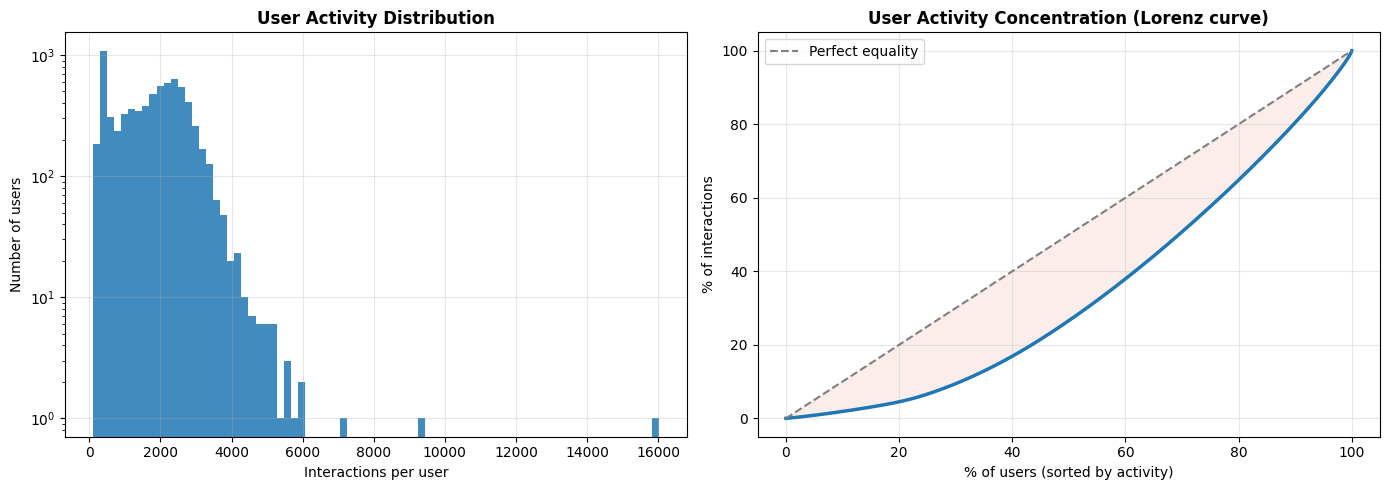

In [ ]:
user_counts = big_df.groupby("user_id").size().sort_values(ascending=False)

print("Interactions per user:")
for q in [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  p{int(q*100):>3}: {user_counts.quantile(q):>8,.0f}")
print(f"  Max: {user_counts.max():>8,}")
print(f"  Mean:{user_counts.mean():>8,.1f}")

total_ints = user_counts.sum()
cumulative = user_counts.cumsum()
n_for_80 = (cumulative <= 0.80 * total_ints).sum() + 1
print(f"\nTop {n_for_80} users ({n_for_80/len(user_counts):.1%}) account for 80% of all interactions")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts, bins=80, alpha=0.85, edgecolor="none")
axes[0].set_xlabel("Interactions per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("User Activity Distribution", fontweight="bold")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

# Lorenz curve for user activity
sorted_counts = np.sort(user_counts.values)
cumsum = np.cumsum(sorted_counts)
user_frac = np.linspace(0, 1, len(sorted_counts))
int_frac  = cumsum / cumsum[-1]
axes[1].plot(user_frac * 100, int_frac * 100, lw=2.5)
axes[1].plot([0, 100], [0, 100], "--", color="gray", lw=1.5, label="Perfect equality")
axes[1].fill_between(user_frac * 100, int_frac * 100, user_frac * 100, alpha=0.12, color="#E07B54")
axes[1].set_xlabel("% of users (sorted by activity)")
axes[1].set_ylabel("% of interactions")
axes[1].set_title("User Activity Concentration (Lorenz curve)", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The user activity distribution is heavily right-skewed — a small fraction of users generate a disproportionate share of interactions, which is a typical pattern in recommendation datasets. The Lorenz curve makes the concentration visible. This has practical consequences: models trained on aggregated interaction counts will naturally bias toward the preferences of the most active users, who may not represent the broader user base. It's also relevant to evaluation — if the test set is drawn from active users, reported metrics will look better than real-world performance on casual users.

### 2.6 Repeat viewing behavior (WR > 1)

Interactions with WR > 1 (replays): 4,237,441  (33.8%)

Among replays:
  Mean WR  : 1.89  (≈ watched 1.9× on avg)
  Median WR: 1.42
  WR > 2   : 22.1%  (watched at least twice fully)
  WR > 5   : 2.7%

Top-replay videos (min 50 views):
          replay_frac  n_views
video_id                      
10157        0.944915      236
2842         0.941176       85
8995         0.938462       65
7523         0.934783       92
5111         0.928571       70


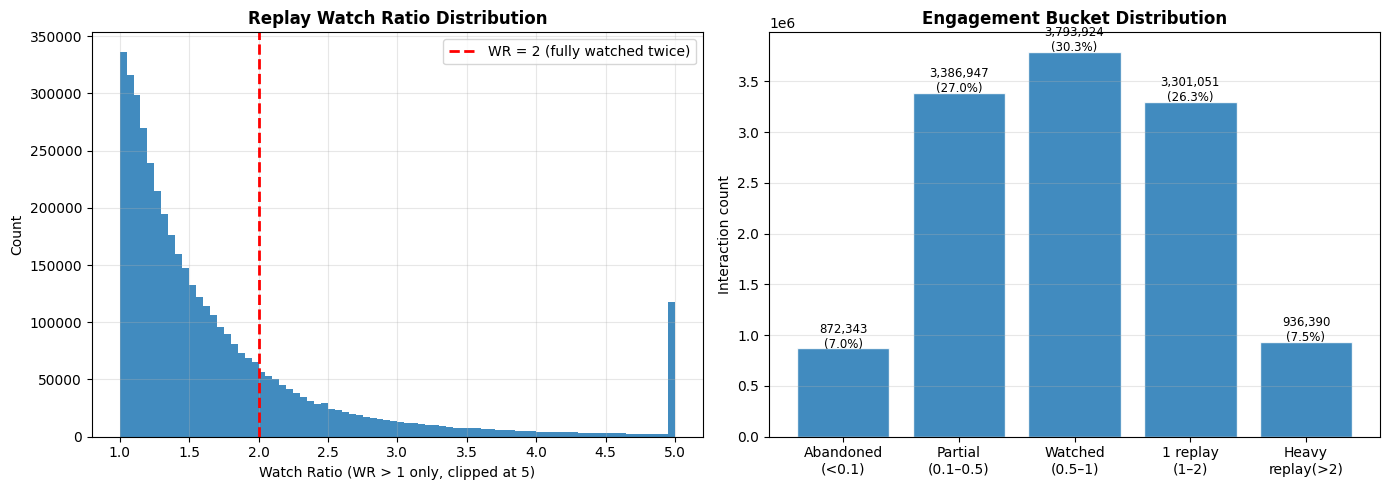

In [ ]:
wr = big_df["watch_ratio"].dropna()

replays = wr[wr > 1]
print(f"Interactions with WR > 1 (replays): {len(replays):,}  ({len(replays)/len(wr):.1%})")
print(f"\nAmong replays:")
print(f"  Mean WR  : {replays.mean():.2f}  (≈ watched {replays.mean():.1f}× on avg)")
print(f"  Median WR: {replays.median():.2f}")
print(f"  WR > 2   : {(replays > 2).mean():.1%}  (watched at least twice fully)")
print(f"  WR > 5   : {(replays > 5).mean():.1%}")

replay_rate = (
    big_df.assign(is_replay=big_df["watch_ratio"] > 1)
    .groupby("video_id")
    .agg(replay_frac=("is_replay", "mean"), n_views=("user_id", "count"))
    .query("n_views >= 50")   # min views for stable estimate
    .sort_values("replay_frac", ascending=False)
)
print(f"\nTop-replay videos (min 50 views):")
print(replay_rate.head(5).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(replays.clip(upper=5), bins=80, alpha=0.85, edgecolor="none")
axes[0].axvline(2.0, ls="--", lw=2, color="red", label="WR = 2 (fully watched twice)")
axes[0].set_xlabel("Watch Ratio (WR > 1 only, clipped at 5)")
axes[0].set_ylabel("Count")
axes[0].set_title("Replay Watch Ratio Distribution", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

buckets = pd.cut(wr,
    bins=[0, 0.1, 0.5, 1.0, 2.0, wr.max() + 1],
    labels=["Abandoned\n(<0.1)", "Partial\n(0.1–0.5)", "Watched\n(0.5–1)", "1 replay\n(1–2)", "Heavy\nreplay(>2)"]
)
bucket_counts = buckets.value_counts().sort_index()
bars = axes[1].bar(bucket_counts.index, bucket_counts.values, alpha=0.85, edgecolor="white")
axes[1].set_ylabel("Interaction count")
axes[1].set_title("Engagement Bucket Distribution", fontweight="bold")
for bar, val in zip(bars, bucket_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5000,
                 f"{val:,}\n({val/len(wr):.1%})", ha="center", fontsize=8.5)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


33.8% of interactions have WR > 1, meaning the user replayed the video at least partially. As on most platforms replay behavior is rare, we have to take into account that this is short content platform.

### 2.7 Watch ratio vs. video duration

Pearson r(duration, WR)      = -0.1440  (p=0)
Spearman rho(duration, WR)   = -0.5123 (p=0)
Pearson r(log1p(duration), WR)= -0.2136 (p=0)


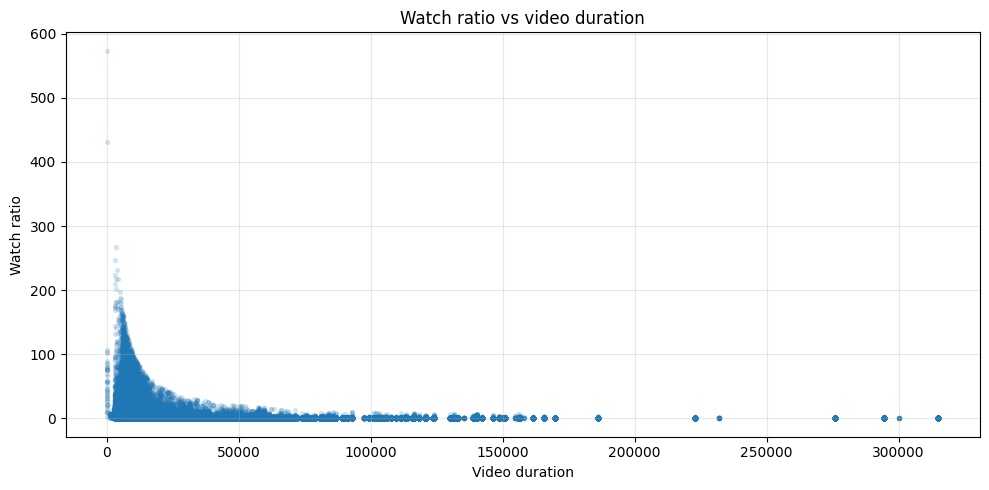

In [ ]:
df = big_df[["watch_ratio", "video_duration"]].dropna().copy()

wr = df["watch_ratio"].to_numpy()
dur = df["video_duration"].to_numpy()

pearson_r, pearson_p = stats.pearsonr(dur, wr)
spearman_rho, spearman_p = stats.spearmanr(dur, wr)

logdur = np.log1p(dur)
pearson_r_log, pearson_p_log = stats.pearsonr(logdur, wr)

print(f"Pearson r(duration, WR)      = {pearson_r:.4f}  (p={pearson_p:.3g})")
print(f"Spearman rho(duration, WR)   = {spearman_rho:.4f} (p={spearman_p:.3g})")
print(f"Pearson r(log1p(duration), WR)= {pearson_r_log:.4f} (p={pearson_p_log:.3g})")

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(dur, wr, s=8, alpha=0.15)
ax.set_xlabel("Video duration")
ax.set_ylabel("Watch ratio")
ax.set_title("Watch ratio vs video duration")

bins = pd.qcut(df["video_duration"], q=20, duplicates="drop")
binned = df.groupby(bins, observed=True).agg(
    dur_mid=("video_duration", "median"),
    wr_mean=("watch_ratio", "mean"),
    wr_med=("watch_ratio", "median"),
    n=("watch_ratio", "size"),
).reset_index(drop=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


There is a clear negative relationship: as videos get longer, users tend to watch a smaller fraction of them. This is intuitive as very short clips are easy to finish (it is also possible that user did not like this, but didn't have time to change the video before it ended). This has practical implications for defining relevance: a raw watch-ratio threshold of 0.7 will be harder to achieve for long videos, which is worth keeping in mind.

### 2.8 Defining relevance

We need a binary relevance label to train and evaluate our rankers. An item is marked **relevant** if the user watched more than 70% of it. This threshold is above 50% as this are short videos, but it's a tunable hyperparameter depending on the use-case.

Small matrix positive rate (WR > 0.7): 56.0%


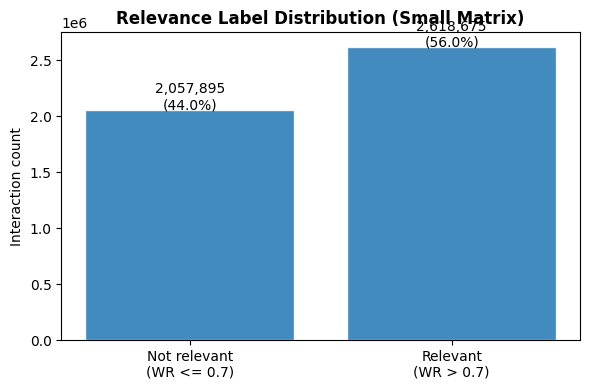

In [ ]:
RELEVANCE_THRESHOLD = 0.7

for df in [big_df, small_df]:
    df["relevant"] = (df["watch_ratio"] > RELEVANCE_THRESHOLD).astype(int)

pos_rate = small_df["relevant"].mean()
print(f"Small matrix positive rate (WR > {RELEVANCE_THRESHOLD}): {pos_rate:.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
counts = small_df["relevant"].value_counts()
ax.bar([f"Not relevant\n(WR <= {RELEVANCE_THRESHOLD})", f"Relevant\n(WR > {RELEVANCE_THRESHOLD})"],
       [counts[0], counts[1]],
       alpha=0.85, edgecolor="white")
ax.set_ylabel("Interaction count")
ax.set_title("Relevance Label Distribution (Small Matrix)", fontweight="bold")
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 500, f"{v:,}\n({v/len(small_df):.1%})", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 3. Train / Test Split

We are going to use small_matrix as the test set as it is dense which allows for evaluation without missing values bias.


In [ ]:
test_users = list(set(small_df["user_id"]))

gt_relevant = (
    small_df[small_df["relevant"] == 1]
    .groupby("user_id")["video_id"]
    .apply(list)
    .to_dict()
)

train_items_per_user = big_df.groupby("user_id")["video_id"].apply(list).to_dict()


## 4. Evaluation Metrics

All models are evaluated at cutoff **K = 20** using standard IR metrics:

- **Precision@K** — of the top-K recommended items, what fraction are relevant?
- **Recall@K** — of all relevant items for a user, what fraction appear in the top-K?
- **DCG@K** — rewards correct recommendations, but discounts hits that appear lower in the ranking
- **nDCG@K** — DCG normalized to [0, 1] by dividing by the ideal (perfect) DCG

nDCG is the primary metric since it captures both relevance and ranking quality.

In [ ]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    hits = sum([1 for item in recommended_k if item in relevant_set])
    return hits / k


def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    hits = sum([1 for item in recommended_k if item in relevant_set])
    return hits / len(relevant_set)


def dcg_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    dcg = 0.0

    for i, item in enumerate(recommended_k):
        if item in relevant:
            dcg += 1 / np.log2(i + 2)
    return dcg


def ndcg_at_k(recommended, relevant, k):
    dcg = dcg_at_k(recommended, relevant, k)

    ideal_relevant = relevant[:k]
    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(relevant), k))])

    if idcg == 0:
        return 0.0

    return dcg / idcg


In [ ]:
def evaluate_model(recommender_fn, test_users, gt_relevant, k=10, desc="Model", top_n =None):
    p_scores, r_scores, n_scores = [], [], []
    for uid in tqdm(test_users, desc=desc, leave=False):
        relevant   = gt_relevant.get(uid, [])
        if not relevant:
            continue
        if top_n is not None:
            recommended = recommender_fn(uid, top_n=top_n)
        else:
            recommended = recommender_fn(uid)
        p_scores.append(precision_at_k(recommended, relevant, k))
        r_scores.append(recall_at_k(recommended, relevant, k))
        n_scores.append(ndcg_at_k(recommended, relevant, k))
    return {
        f"Precision@{k}": np.mean(p_scores),
        f"Recall@{k}":    np.mean(r_scores),
        f"nDCG@{k}":      np.mean(n_scores),
    }

In [ ]:
K_EVAL = 20
print(f"Evaluation will use K = {K_EVAL}")

Evaluation will use K = 20


## 5. Models



In [ ]:
results = {} # here we gonna store results

### 5.1 Popularity Baseline

The simplest possible recommender: recommend the most-watched videos globally, excluding items the user has already interacted with. This is a strong heuristic in practice as popular content is popular for a reason.

In [ ]:
item_popularity = (
    big_df[big_df["relevant"] == 1]
    .groupby("video_id")["user_id"]
    .count()
    .sort_values(ascending=False)
)

popular_items = item_popularity.index.tolist()

def popularity_recommender(user_id, n=200):
    seen = set(train_items_per_user.get(user_id, []))
    return [v for v in popular_items if v not in seen][:n]

In [ ]:
results["Popularity Baseline"] = evaluate_model(
    popularity_recommender, test_users, gt_relevant, k=K_EVAL, desc="Popularity"
)

Popularity:   0%|          | 0/1411 [00:00<?, ?it/s]

In [ ]:
print(results["Popularity Baseline"])

{'Precision@20': np.float64(0.7951452870304748), 'Recall@20': np.float64(0.008660510567009477), 'nDCG@20': np.float64(0.7726809101312401)}


### 5.2 User-Based Collaborative Filtering

Users with similar tastes probably tend to watch similar videos. We compute cosine similarity between user interaction vectors, then score candidate items using a weighted sum over the top-K nearest neighbors. Items already seen by the target user are excluded from recommendations.

In [ ]:
all_users = big_df["user_id"].unique()
all_items = big_df["video_id"].unique()

user_idx  = {u: i for i, u in enumerate(all_users)}
item_idx  = {v: i for i, v in enumerate(all_items)}

rows = big_df["user_id"].map(user_idx)
cols = big_df["video_id"].map(item_idx)
data = big_df["watch_ratio"].fillna(0).values

train_matrix = sparse.csr_matrix(
    (data, (rows, cols)),
    shape=(len(all_users), len(all_items))
)

print(f"Train matrix shape: {train_matrix.shape}  nnz={train_matrix.nnz:,}")
print("Computing user-user cosine similarities ...")

# to keep RAM low
test_user_indices = np.array([user_idx[u] for u in test_users if u in user_idx])
test_submatrix = train_matrix[test_user_indices]  # (n_test, n_items)

user_sim = cosine_similarity(test_submatrix, train_matrix)  # (n_test, n_all_users)
print(f"Similarity matrix shape: {user_sim.shape}")


Train matrix shape: (7176, 10728)  nnz=10,300,969
Computing user-user cosine similarities ...
Similarity matrix shape: (1411, 7176)


In [ ]:
# Precompute reverse maps
idx_to_item = {i: v for v, i in item_idx.items()}
test_uid_to_sim_row = {uid: i for i, uid in enumerate(test_users) if uid in user_idx}

TOP_N_NEIGHBORS = 50

def cf_recommender(user_id, n=200, top_n=50):
    if user_id not in test_uid_to_sim_row:
        return popularity_recommender(user_id, n)

    sim_row_idx = test_uid_to_sim_row[user_id]
    sims = user_sim[sim_row_idx]

    # Get top neighbors (excluding self)
    u_idx = user_idx[user_id]
    sims[u_idx] = -1
    top_neighbors = np.argpartition(sims, -top_n)[-top_n:]
    top_neighbors = top_neighbors[np.argsort(sims[top_neighbors])[::-1]]

    neighbor_sims   = sims[top_neighbors]
    neighbor_matrix = train_matrix[top_neighbors].toarray()   # (k, n_items)
    scores = neighbor_sims @ neighbor_matrix                   # (n_items,)

    # Exclude items already seen by user!
    seen_item_indices = set(train_matrix[u_idx].indices)
    for idx in seen_item_indices:
        scores[idx] = -1

    top_item_indices = np.argsort(scores)[::-1][:n]
    return [idx_to_item[i] for i in top_item_indices if i in idx_to_item]


Let's evaluate different values for the number of nearest neighbors on a held-out subset before committing to the full evaluation.

In [ ]:
for top_neighbours in [1, 3, 10, 30, 50, 100]:
  print(f"Top neighbours = {top_neighbours} \n", evaluate_model(
    cf_recommender, test_users[:500], gt_relevant, k=K_EVAL, desc="User-CF", top_n = top_neighbours))

User-CF:   0%|          | 0/500 [00:00<?, ?it/s]

Top neighbours = 1 
 {'Precision@20': np.float64(0.022699999999999998), 'Recall@20': np.float64(0.00026019265173048324), 'nDCG@20': np.float64(0.02378702122292927)}


User-CF:   0%|          | 0/500 [00:00<?, ?it/s]

Top neighbours = 3 
 {'Precision@20': np.float64(0.033600000000000005), 'Recall@20': np.float64(0.0004036004405749899), 'nDCG@20': np.float64(0.035189776469273196)}


User-CF:   0%|          | 0/500 [00:00<?, ?it/s]

...

Top neighbours = 30 
 {'Precision@20': np.float64(0.0199), 'Recall@20': np.float64(0.00024103744923138038), 'nDCG@20': np.float64(0.021683332954272595)}


User-CF:   0%|          | 0/500 [00:00<?, ?it/s]

Top neighbours = 50 
 {'Precision@20': np.float64(0.013200000000000002), 'Recall@20': np.float64(0.0001576911238611946), 'nDCG@20': np.float64(0.014372986440796336)}


User-CF:   0%|          | 0/500 [00:00<?, ?it/s]

Top neighbours = 100 
 {'Precision@20': np.float64(0.007300000000000001), 'Recall@20': np.float64(8.573174060919301e-05), 'nDCG@20': np.float64(0.0070153671831416865)}


In [ ]:
results["User-Based CF"] = evaluate_model(
    cf_recommender, test_users, gt_relevant, k=K_EVAL, desc="User-CF", top_n = 3)
print(results["User-Based CF"])

User-CF:   0%|          | 0/1411 [00:00<?, ?it/s]

{'Precision@20': np.float64(0.032246633593196315), 'Recall@20': np.float64(0.0003805644082858581), 'nDCG@20': np.float64(0.03244771525873829)}


### 5.3 Content-Based Filtering

A user who enjoyed cat videos probably wants more cat videos. We represent each video as a multi-hot category vector and build a user profile as the average feature vector of their liked items. Items are then ranked by cosine similarity to the user profile. This approach is purely interest-driven and doesn't require any interaction data from other users.

In [ ]:
all_video_ids = item_categories["video_id"].values

mlb = MultiLabelBinarizer(sparse_output=False)
cat_matrix = mlb.fit_transform(item_categories["feat"])

item_feat_df = pd.DataFrame(
    cat_matrix,
    index=item_categories["video_id"],
    columns=mlb.classes_
)
common_items = set(item_feat_df.index) & set(all_items)
feat_matrix  = item_feat_df.loc[list(common_items)].values.astype(np.float32)
feat_items   = list(common_items)
feat_item_idx = {v: i for i, v in enumerate(feat_items)}

print(f"Items with feature vectors: {len(feat_items):,}")

liked_by_user = (
    big_df[big_df["relevant"] == 1]
    .groupby("user_id")["video_id"]
    .apply(list)
    .to_dict()
)

def get_user_profile(user_id):
    liked = [v for v in liked_by_user.get(user_id, []) if v in feat_item_idx]
    if not liked:
        return None
    indices = [feat_item_idx[v] for v in liked]
    return feat_matrix[indices].mean(axis=0, keepdims=True)  # (1, n_cats)

def content_recommender(user_id, n=200):
    profile = get_user_profile(user_id)
    if profile is None:
        return popularity_recommender(user_id, n)

    sims    = cosine_similarity(profile, feat_matrix).flatten()   # (n_items,)
    seen    = set(train_items_per_user.get(user_id, []))

    ranked  = np.argsort(sims)[::-1]
    return [feat_items[i] for i in ranked if feat_items[i] not in seen][:n]


Items with feature vectors: 10,728


In [ ]:
results["Content-Based"] = evaluate_model(
    content_recommender, test_users, gt_relevant, k=K_EVAL, desc="Content"
)

Content:   0%|          | 0/1411 [00:00<?, ?it/s]

In [ ]:
print(results["Content-Based"])

{'Precision@20': np.float64(0.48823529411764705), 'Recall@20': np.float64(0.005275705259224801), 'nDCG@20': np.float64(0.4839908228286636)}


### 5.4 Hybrid Model (CF + Content)

Combining both signals tepretically gives us the best of both worlds — CF captures user-level behavioral patterns, while content-based filtering gives recommendations to the user's demonstrated topic interests. The mixing parameter `alpha` is tuned on a small validation subset.

In [ ]:
# CF scores
cf_scores_cache = {}
for uid in tqdm(test_users, desc="CF cache"):
    if uid not in test_uid_to_sim_row or uid not in user_idx:
        cf_scores_cache[uid] = None
        continue
    sim_row_idx = test_uid_to_sim_row[uid]
    sims = user_sim[sim_row_idx].copy()
    sims[user_idx[uid]] = -1          # mask self
    top_nb = np.argpartition(sims, -TOP_N_NEIGHBORS)[-TOP_N_NEIGHBORS:]
    top_nb = top_nb[np.argsort(sims[top_nb])[::-1]]
    nb_sims = sims[top_nb]
    nb_mat  = train_matrix[top_nb].toarray()
    cf_scores_cache[uid] = nb_sims @ nb_mat

CF cache:   0%|          | 0/1411 [00:00<?, ?it/s]

In [ ]:
# Content score
cb_scores_cache = {}
for uid in tqdm(test_users, desc="Content cache"):
    profile = get_user_profile(uid)
    if profile is None:
        cb_scores_cache[uid] = None
        continue
    cb_scores_cache[uid] = cosine_similarity(profile, feat_matrix).flatten()


Content cache:   0%|          | 0/1411 [00:00<?, ?it/s]

In [ ]:
def hybrid_recommender(user_id, alpha=0.6, n=200):
    seen = set(train_items_per_user.get(user_id, []))

    cf_vec = cf_scores_cache.get(user_id)
    cb_vec = cb_scores_cache.get(user_id)

    if cf_vec is not None:
        cf_max = cf_vec.max()
        cf_norm = cf_vec / (cf_max + 1e-9)
        cf_dict = {idx_to_item[i]: cf_norm[i] for i in range(len(cf_norm)) if i in idx_to_item}
    else:
        cf_dict = {}

    if cb_vec is not None:
        cb_max = cb_vec.max()
        cb_norm = cb_vec / (cb_max + 1e-9)
        cb_dict = {feat_items[i]: float(cb_norm[i]) for i in range(len(cb_norm))}
    else:
        cb_dict = {}

    all_candidates = set(cf_dict.keys()) | set(cb_dict.keys())
    all_candidates -= seen

    scores = {
        v: alpha * cf_dict.get(v, 0.0) + (1 - alpha) * cb_dict.get(v, 0.0)
        for v in all_candidates
    }
    ranked = sorted(scores, key=scores.__getitem__, reverse=True)
    return ranked[:n]


val_users = test_users[:100]
best_alpha, best_ndcg = 0.5, -1

print("Grid-searching alpha ...")
for alpha in tqdm([0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], desc="alpha"):
    res = evaluate_model(
        lambda uid, a=alpha: hybrid_recommender(uid, alpha=a),
        val_users, gt_relevant, k=K_EVAL, desc=""
    )
    ndcg = res[f"nDCG@{K_EVAL}"]
    if ndcg > best_ndcg:
        best_ndcg, best_alpha = ndcg, alpha

print(f"\nBest alpha = {best_alpha}  (val nDCG@{K_EVAL} = {best_ndcg:.4f})")


Grid-searching alpha ...


alpha:   0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]


Best alpha = 0.01  (val nDCG@20 = 0.2935)


In [ ]:
results["Hybrid (CF + Content)"] = evaluate_model(
    lambda uid: hybrid_recommender(uid, alpha=best_alpha),
    test_users, gt_relevant, k=K_EVAL, desc="Hybrid"
)


Hybrid:   0%|          | 0/1411 [00:00<?, ?it/s]

In [ ]:
print(results["Hybrid (CF + Content)"])

{'Precision@20': np.float64(0.2942239546420978), 'Recall@20': np.float64(0.0031811931349857788), 'nDCG@20': np.float64(0.2852444155750314)}


### So far results summary

Quick note on Recall@20: the values look tiny but that's expected. The small matrix has a high positive rate, so the average user has a lot relevant items. Finding 20 of those gives small values as the denominator is just very large. nDCG@20 and Precision@20 are the main metrics to focus on.

In [ ]:
print(pd.DataFrame(results).T.to_string(float_format="{:.4f}".format))

                       Precision@20  Recall@20  nDCG@20
Popularity Baseline          0.7951     0.0087   0.7727
User-Based CF                0.0322     0.0004   0.0324
Content-Based                0.4882     0.0053   0.4840
Hybrid (CF + Content)        0.2942     0.0032   0.2852


Popularity wins by a huge margin, which is the expected consequence of training on data generated by Kuaishou's own recommender. The feedback loop means popular items accumulate more interactions and look more "relevant" in the training data.

Content-based filtering does reasonably well (nDCG 0.48), which makes sense: 31 categories is a small feature space but it still captures something real about user tastes.

User-Based CF is a near-failure (nDCG 0.03). The most likely reason is sparsity in a less obvious sense— the big matrix is 84% sparse, and with only 3 neighbors, the CF scores are very noisy. Short-form video platforms also tend to have homogeneous behavior patterns: everyone watches trending content, so cosine similarity between users doesn't differentiate well. The hybrid inherits this problem.

## 6. Addressing Popularity Bias

> Add blockquote



Top 1%  of items account for 6.0% of all interactions
Top 10% of items account for 40.7% of all interactions
Bottom 50% of items account for only 2.6% of interactions


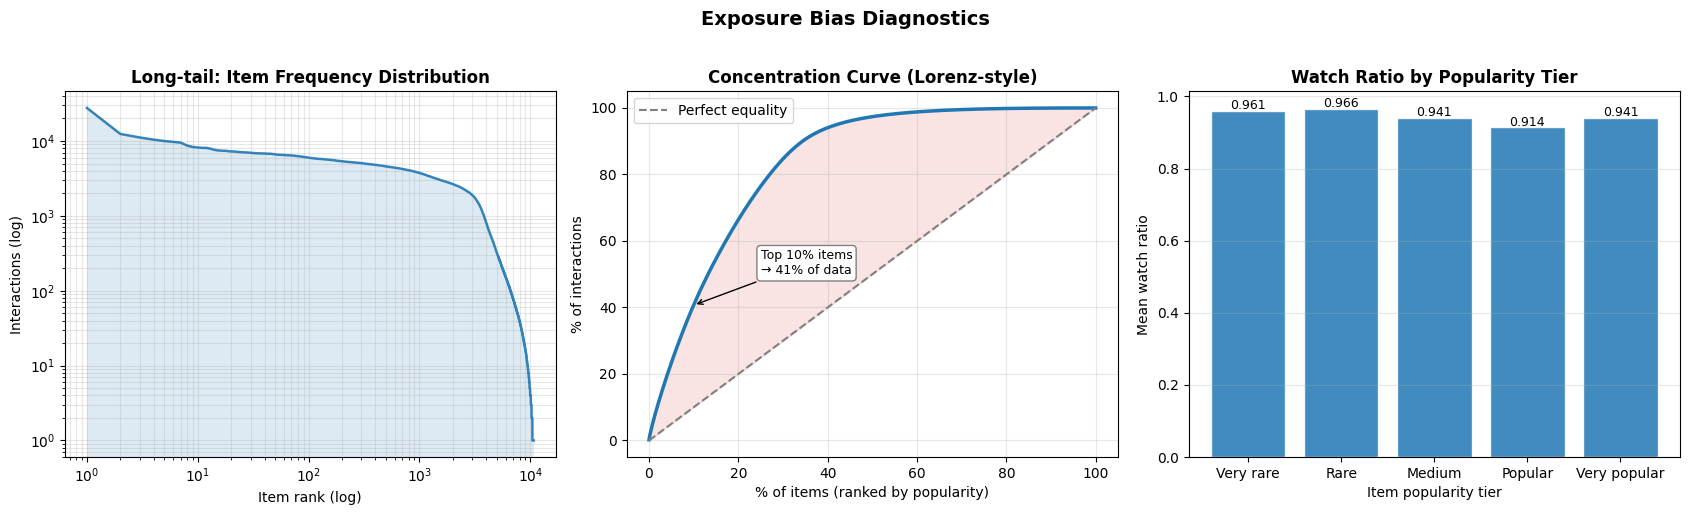

In [ ]:
item_freq = big_df.groupby("video_id").size().sort_values(ascending=False).reset_index()
item_freq.columns = ["video_id", "n_interactions"]
item_freq["rank"] = np.arange(1, len(item_freq) + 1)

total_interactions = item_freq["n_interactions"].sum()
item_freq["cumulative_frac"] = item_freq["n_interactions"].cumsum() / total_interactions
item_freq["item_frac"] = item_freq["rank"] / len(item_freq)

top10_share  = item_freq[item_freq["item_frac"] <= 0.10]["n_interactions"].sum() / total_interactions
top1_share   = item_freq[item_freq["item_frac"] <= 0.01]["n_interactions"].sum() / total_interactions
bottom50_share = item_freq[item_freq["item_frac"] >= 0.50]["n_interactions"].sum() / total_interactions

print(f"Top 1%  of items account for {top1_share:.1%} of all interactions")
print(f"Top 10% of items account for {top10_share:.1%} of all interactions")
print(f"Bottom 50% of items account for only {bottom50_share:.1%} of interactions")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].loglog(item_freq["rank"], item_freq["n_interactions"],
               lw=1.8,  alpha=0.9)
axes[0].fill_between(item_freq["rank"], item_freq["n_interactions"],
                     alpha=0.15)
axes[0].set_xlabel("Item rank (log)")
axes[0].set_ylabel("Interactions (log)")
axes[0].set_title("Long-tail: Item Frequency Distribution", fontweight="bold")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].plot(item_freq["item_frac"] * 100, item_freq["cumulative_frac"] * 100,
             lw=2.5)
axes[1].plot([0, 100], [0, 100], "--", color="gray", lw=1.5, label="Perfect equality")
axes[1].fill_between(item_freq["item_frac"] * 100,
                     item_freq["cumulative_frac"] * 100,
                     item_freq["item_frac"] * 100, alpha=0.15, color="#DD4444")
axes[1].set_xlabel("% of items (ranked by popularity)")
axes[1].set_ylabel("% of interactions")
axes[1].set_title("Concentration Curve (Lorenz-style)", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].annotate(f"Top 10% items\n→ {top10_share:.0%} of data",
                 xy=(10, item_freq[item_freq["item_frac"] <= 0.10]["cumulative_frac"].max() * 100),
                 xytext=(25, 50), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="black"),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))

# Watch ratio vs popularity
item_freq["log_freq"] = np.log1p(item_freq["n_interactions"])
merged = big_df.merge(item_freq[["video_id", "n_interactions"]], on="video_id", how="left")
merged["pop_tier"] = pd.qcut(merged["n_interactions"], q=5,
                              labels=["Very rare", "Rare", "Medium", "Popular", "Very popular"])
tier_wr = merged.groupby("pop_tier", observed=True)["watch_ratio"].mean()
bars = axes[2].bar(tier_wr.index, tier_wr.values, alpha=0.85, edgecolor="white")
axes[2].set_xlabel("Item popularity tier")
axes[2].set_ylabel("Mean watch ratio")
axes[2].set_title("Watch Ratio by Popularity Tier", fontweight="bold")
for bar, val in zip(bars, tier_wr.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f"{val:.3f}", ha="center", fontsize=9)
axes[2].grid(True, axis="y", alpha=0.3)

plt.suptitle("Exposure Bias Diagnostics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


The item interaction distribution is strongly long-tailed, with a small fraction of videos receiving a disproportionate share of attention. Mean watch ratio is relatively similar across popularity tiers, suggesting that the app recommendation system is good working - the users which were exposed to unpopular videos founded them relevant.

### 6.1 Propensity Estimation

We model propensity as the probability that the system exposed a user to an item, estimated by item frequency (normalized by the max). Inverse Propensity Scoring (IPS) then up-weights outcomes from rarely seen items and down-weights those from popular ones.

Formally, the IPS weight for item $i$ is $w_i = 1 / P(i)$. Since extreme weights can destabilize learning, we clip propensity from below at a threshold $\tau$, capping the maximum IPS weight at $1/\tau$.

Propensity stats (raw):
  min=0.00004  max=1.000  mean=0.0423
IPS weight stats (raw):
  min=1.00  max=27615.0  mean=1682.23
IPS weight stats (clipped at τ=0.05):
  min=1.00  max=20.0  mean=16.79


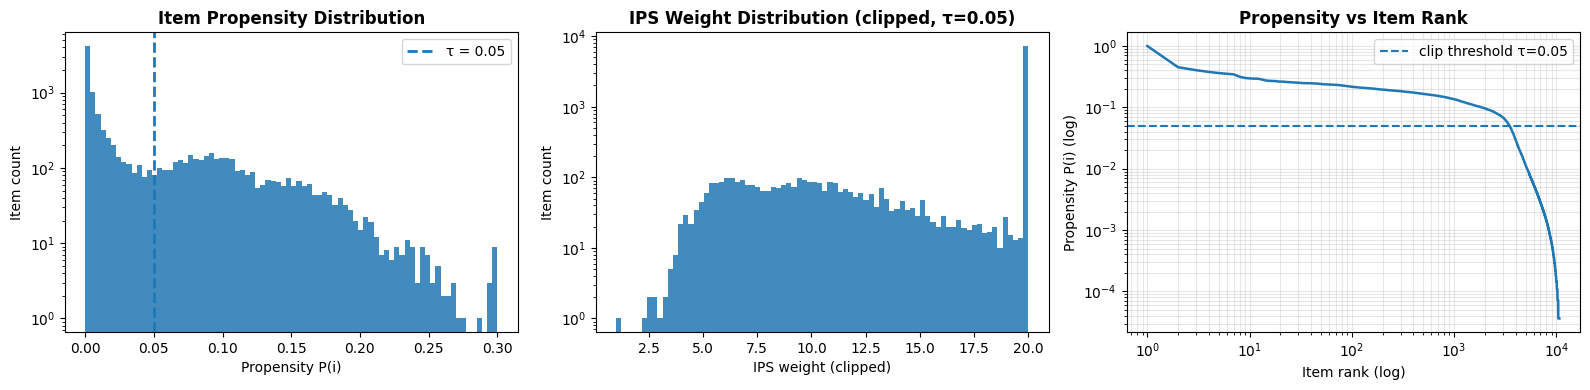

In [ ]:
all_item_counts = big_df.groupby("video_id").size()
train_df = big_df[big_df["relevant"] == 1][["user_id", "video_id"]].drop_duplicates()

bpr_users = sorted(train_df["user_id"].unique())
bpr_items = sorted(train_df["video_id"].unique())
n_users = len(bpr_users)
n_items = len(bpr_items)
bpr_u2i   = {u: i for i, u in enumerate(bpr_users)}
bpr_i2i   = {v: i for i, v in enumerate(bpr_items)}
bpr_i2v   = {i: v for v, i in bpr_i2i.items()}
item_counts_bpr = pd.Series(
    {bpr_i2i[v]: all_item_counts.get(v, 1)
     for v in bpr_i2i.keys()}
)

max_count = item_counts_bpr.max()

propensity_raw = item_counts_bpr / max_count

TAU = 0.05
propensity_clipped = propensity_raw.clip(lower=TAU)

ips_weights_raw     = 1.0 / propensity_raw
ips_weights_clipped = 1.0 / propensity_clipped

ips_raw_arr  = np.ones(n_items, dtype=np.float32)
ips_clip_arr = np.ones(n_items, dtype=np.float32)
for item_idx, w_raw, w_clip in zip(item_counts_bpr.index,
                                    ips_weights_raw.values,
                                    ips_weights_clipped.values):
    ips_raw_arr[item_idx]  = w_raw
    ips_clip_arr[item_idx] = w_clip

print(f"Propensity stats (raw):")
print(f"  min={propensity_raw.min():.5f}  max={propensity_raw.max():.3f}  mean={propensity_raw.mean():.4f}")
print(f"IPS weight stats (raw):")
print(f"  min={ips_weights_raw.min():.2f}  max={ips_weights_raw.max():.1f}  mean={ips_weights_raw.mean():.2f}")
print(f"IPS weight stats (clipped at τ={TAU}):")
print(f"  min={ips_weights_clipped.min():.2f}  max={ips_weights_clipped.max():.1f}  mean={ips_weights_clipped.mean():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(propensity_raw.clip(upper=0.3), bins=80, alpha=0.85, edgecolor="none")
axes[0].axvline(TAU, ls="--", lw=2, label=f"τ = {TAU}")
axes[0].set_xlabel("Propensity P(i)")
axes[0].set_ylabel("Item count")
axes[0].set_title("Item Propensity Distribution", fontweight="bold")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].hist(ips_weights_clipped, bins=80,  alpha=0.85, edgecolor="none")
axes[1].set_xlabel("IPS weight (clipped)")
axes[1].set_ylabel("Item count")
axes[1].set_title(f"IPS Weight Distribution (clipped, τ={TAU})", fontweight="bold")
axes[1].set_yscale("log")

sorted_props = np.sort(propensity_raw.values)[::-1]
axes[2].loglog(np.arange(1, len(sorted_props)+1), sorted_props,
               lw=1.8,)
axes[2].axhline(TAU, ls="--", lw=1.5, label=f"clip threshold τ={TAU}")
axes[2].set_xlabel("Item rank (log)")
axes[2].set_ylabel("Propensity P(i) (log)")
axes[2].set_title("Propensity vs Item Rank", fontweight="bold")
axes[2].legend()
axes[2].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


### 6.2 IPS-Weighted Models

We rebuild the user–item matrix with IPS-weighted interaction values and re-run both CF and content-based filtering, as well as a new debiased hybrid.

In [ ]:
all_items = big_df["video_id"].unique()
item_idx  = {v: i for i, v in enumerate(all_items)}

vid_ips_weight: dict = {}
_max_cnt = all_item_counts.max()
for vid, cnt in all_item_counts.items():
    raw_p = cnt / _max_cnt
    clip_p = max(raw_p, TAU)
    vid_ips_weight[vid] = 1.0 / clip_p

rows_cf = big_df["user_id"].map(user_idx)
cols_cf = big_df["video_id"].map(item_idx)
ips_vals = (
    big_df["watch_ratio"].fillna(0).values
    * big_df["video_id"].map(vid_ips_weight).fillna(1.0).values
)

train_matrix_ips = sparse.csr_matrix(
    (ips_vals, (rows_cf, cols_cf)),
    shape=(len(all_users), len(all_items))
)

print(f"IPS-weighted train matrix: shape={train_matrix_ips.shape}  nnz={train_matrix_ips.nnz:,}")

test_submatrix_ips = train_matrix_ips[
    np.array([user_idx[u] for u in test_users if u in user_idx])
]

IPS-weighted train matrix: shape=(7176, 10728)  nnz=10,300,969


In [ ]:
user_sim_ips = cosine_similarity(test_submatrix_ips, train_matrix_ips)


In [ ]:
cf_scores_ips_cache = {}
for uid in tqdm(test_users, desc="IPS-CF cache"):
    if uid not in test_uid_to_sim_row or uid not in user_idx:
        cf_scores_ips_cache[uid] = None
        continue

    sim_row_idx = test_uid_to_sim_row[uid]
    sims = user_sim_ips[sim_row_idx].copy()
    sims[user_idx[uid]] = -1

    top_nb = np.argpartition(sims, -TOP_N_NEIGHBORS)[-TOP_N_NEIGHBORS:]
    top_nb = top_nb[np.argsort(sims[top_nb])[::-1]]

    nb_sims = sims[top_nb]
    nb_mat  = train_matrix_ips[top_nb].toarray()
    cf_scores_ips_cache[uid] = nb_sims @ nb_mat    # shape (n_all_items,)

print("Done.")

def ips_cf_recommender(user_id, n=200):
    seen   = set(train_items_per_user.get(user_id, []))
    cf_vec = cf_scores_ips_cache.get(user_id)

    if cf_vec is None:
        return popularity_recommender(user_id, n)

    cf_max  = cf_vec.max()
    cf_norm = cf_vec / (cf_max + 1e-9)
    scores  = {idx_to_item[i]: cf_norm[i]
               for i in range(len(cf_norm)) if i in idx_to_item and idx_to_item[i] not in seen}
    return sorted(scores, key=scores.__getitem__, reverse=True)[:n]

results["IPS-CF"] = evaluate_model(
    ips_cf_recommender, test_users, gt_relevant, k=K_EVAL, desc="IPS-CF"
)
print(f"IPS-CF:       {results['IPS-CF']}")
print(f"Without IPS CF:   {results['User-Based CF']}")


IPS-CF cache:   0%|          | 0/1411 [00:00<?, ?it/s]

Done.


IPS-CF:   0%|          | 0/1411 [00:00<?, ?it/s]

IPS-CF:       {'Precision@20': np.float64(0.016513111268603824), 'Recall@20': np.float64(0.0001997212588195507), 'nDCG@20': np.float64(0.019239598078919888)}
Without IPS CF:   {'Precision@20': np.float64(0.032246633593196315), 'Recall@20': np.float64(0.0003805644082858581), 'nDCG@20': np.float64(0.03244771525873829)}


In [ ]:
def get_user_profile_ips(user_id):

    liked   = [v for v in liked_by_user.get(user_id, []) if v in feat_item_idx]
    if not liked:
        return None
    indices = [feat_item_idx[v] for v in liked]
    weights = np.array([vid_ips_weight.get(v, 1.0) for v in liked], dtype=np.float32)
    weights /= weights.sum()                              # normalise to sum=1
    # Weighted average: (n_liked, n_cats) · (n_liked,) → (n_cats,)
    profile = (feat_matrix[indices] * weights[:, None]).sum(axis=0, keepdims=True)
    return profile.astype(np.float32)                     # (1, n_cats)


cb_scores_ips_cache = {}
for uid in tqdm(test_users, desc="IPS-Content cache"):
    profile = get_user_profile_ips(uid)
    if profile is None:
        cb_scores_ips_cache[uid] = None
        continue
    cb_scores_ips_cache[uid] = cosine_similarity(profile, feat_matrix).flatten()


def ips_content_recommender(user_id, n=200):
    seen   = set(train_items_per_user.get(user_id, []))
    cb_vec = cb_scores_ips_cache.get(user_id)

    if cb_vec is None:
        return popularity_recommender(user_id, n)

    ranked = np.argsort(cb_vec)[::-1]
    return [feat_items[i] for i in ranked
            if feat_items[i] not in seen][:n]

results["IPS-Content"] = evaluate_model(
    ips_content_recommender, test_users, gt_relevant, k=K_EVAL, desc="IPS-Content"
)
print(f"IPS-Content:       {results['IPS-Content']}")
print(f"Vanilla Content:   {results['Content-Based']}")


IPS-Content cache:   0%|          | 0/1411 [00:00<?, ?it/s]

IPS-Content:   0%|          | 0/1411 [00:00<?, ?it/s]

IPS-Content:       {'Precision@20': np.float64(0.4689581856839122), 'Recall@20': np.float64(0.005040188059064896), 'nDCG@20': np.float64(0.467274864926195)}
Vanilla Content:   {'Precision@20': np.float64(0.48823529411764705), 'Recall@20': np.float64(0.005275705259224801), 'nDCG@20': np.float64(0.4839908228286636)}


In [ ]:
def ips_hybrid_recommender(user_id, alpha=0.6, n=200):
    seen   = set(train_items_per_user.get(user_id, []))
    cf_vec = cf_scores_ips_cache.get(user_id)
    cb_vec = cb_scores_ips_cache.get(user_id)

    if cf_vec is not None:
        cf_norm = cf_vec / (cf_vec.max() + 1e-9)
        cf_dict = {idx_to_item[i]: float(cf_norm[i])
                   for i in range(len(cf_norm)) if i in idx_to_item}
    else:
        cf_dict = {}

    if cb_vec is not None:
        cb_norm = cb_vec / (cb_vec.max() + 1e-9)
        cb_dict = {feat_items[i]: float(cb_norm[i]) for i in range(len(cb_norm))}
    else:
        cb_dict = {}

    candidates = (set(cf_dict) | set(cb_dict)) - seen
    scores     = {v: alpha * cf_dict.get(v, 0.0) + (1 - alpha) * cb_dict.get(v, 0.0)
                  for v in candidates}
    return sorted(scores, key=scores.__getitem__, reverse=True)[:n]


val_users = test_users[:100]
best_alpha_ips, best_ndcg_ips = 0.5, -1.0


for alpha in tqdm([0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], desc="alpha"):
    res = evaluate_model(
        lambda uid, a=alpha: ips_hybrid_recommender(uid, alpha=a),
        val_users, gt_relevant, k=K_EVAL, desc=""
    )
    if res[f"nDCG@{K_EVAL}"] > best_ndcg_ips:
        best_ndcg_ips  = res[f"nDCG@{K_EVAL}"]
        best_alpha_ips = alpha

print(f"\nBest alpha (IPS-Hybrid) = {best_alpha_ips}  (val nDCG@{K_EVAL} = {best_ndcg_ips:.4f})")

results["IPS-Hybrid"] = evaluate_model(
    lambda uid: ips_hybrid_recommender(uid, alpha=best_alpha_ips),
    test_users, gt_relevant, k=K_EVAL, desc="IPS-Hybrid"
)
print(f"IPS-Hybrid:       {results['IPS-Hybrid']}")
print(f"Vanilla Hybrid:   {results['Hybrid (CF + Content)']}")


alpha:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]


Best alpha (IPS-Hybrid) = 0.01  (val nDCG@20 = 0.3225)


IPS-Hybrid:   0%|          | 0/1411 [00:00<?, ?it/s]

IPS-Hybrid:       {'Precision@20': np.float64(0.3058114812189936), 'Recall@20': np.float64(0.0033125984566820493), 'nDCG@20': np.float64(0.3029326001389682)}
Vanilla Hybrid:   {'Precision@20': np.float64(0.2942239546420978), 'Recall@20': np.float64(0.0031811931349857788), 'nDCG@20': np.float64(0.2852444155750314)}


One thing worth flagging: IPS-CF
 is actually worse than vanilla CF and IPS-Hybrid is roughly tied with vanilla Hybrid. The IPS reweighting amplifies rare items in the user-similarity calculation, which adds noise on top of already noisy CF scores. For the content-based side, IPS has minimal impact since the category features are sparse enough that reweighting doesn't shift the cosine similarities much. IPS is doing what it's supposed to theoretically, but the CF component is too weak for the correction to help.

## 7. Watch Ratio Prediction Model

 A different angle is to directly predict the watch ratio for each (user, item) pair and rank by predicted engagement.

It means we look at recommendation as at a regression problem.

One thing to be upfront about: the model will learn from the same biased training data. If item_mean_wr ends up being the dominant feature, that means the model is essentially re-learning popularity ordering with a thin layer of personalization on top.

In [ ]:
user_stats = big_df.groupby("user_id").agg(
    user_mean_wr   = ("watch_ratio", "mean"),
    user_median_wr = ("watch_ratio", "median"),
    user_n_inter   = ("video_id",    "count"),
    user_frac_rel  = ("relevant",    "mean"),
).reset_index()

item_stats = big_df.groupby("video_id").agg(
    item_mean_wr   = ("watch_ratio", "mean"),
    item_median_wr = ("watch_ratio", "median"),
    item_n_inter   = ("user_id",     "count"),
    item_frac_rel  = ("relevant",    "mean"),
).reset_index()

# Item popularity rank (1 = most popular)
item_stats["item_pop_rank"] = item_stats["item_n_inter"].rank(ascending=False).astype(int)

cat_mean = pd.DataFrame(
    cat_matrix,
    index=item_categories["video_id"]
).groupby(level=0).mean()     # handles any duplicate video_ids
cat_mean.columns = [f"cat_{c}" for c in cat_mean.columns]
cat_mean = cat_mean.reset_index().rename(columns={"video_id": "video_id"})

print(f"User stats shape : {user_stats.shape}")
print(f"Item stats shape : {item_stats.shape}")
print(f"Category features: {cat_mean.shape}")


User stats shape : (7176, 5)
Item stats shape : (10728, 6)
Category features: (10728, 32)


In [ ]:
from sklearn.model_selection import train_test_split

try:
    import lightgbm as lgb
    USE_LGB = True
except ImportError:
    USE_LGB = False

# Subsample for speed — 500k is plenty for this feature set
train_sample = big_df[["user_id", "video_id", "watch_ratio", "hour"]].dropna().sample(
    n=min(500_000, len(big_df)), random_state=SEED
)

train_feat = (
    train_sample
    .merge(user_stats, on="user_id",  how="left")
    .merge(item_stats, on="video_id", how="left")
    .merge(cat_mean,   on="video_id", how="left")
    .fillna(0)
)

feature_cols = (
    ["user_mean_wr", "user_median_wr", "user_n_inter", "user_frac_rel",
     "item_mean_wr", "item_median_wr", "item_n_inter", "item_frac_rel",
     "item_pop_rank", "hour"]
    + [c for c in train_feat.columns if c.startswith("cat_")]
)

X_all = train_feat[feature_cols].values
y_all = train_feat["watch_ratio"].values

X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.1, random_state=SEED)

print(f"Training on {X_tr.shape[0]:,} samples, validating on {X_val.shape[0]:,}, {X_tr.shape[1]} features")

if USE_LGB:
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    params = {
        "objective":        "regression",
        "metric":           "rmse",
        "learning_rate":    0.05,
        "num_leaves":       63,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "verbose":          -1,
        "random_state":     SEED,
    }
    wr_model = lgb.train(
        params, dtrain,
        num_boost_round=500,
        valid_sets=[dtrain, dval],
        valid_names=["train", "val"],
        callbacks=[
            lgb.log_evaluation(period=100),
            lgb.early_stopping(stopping_rounds=30, verbose=False)
        ]
    )
    def predict_fn(X): return wr_model.predict(X)
else:
    from sklearn.ensemble import GradientBoostingRegressor
    wr_model = GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, subsample=0.8, random_state=SEED
    )
    wr_model.fit(X_tr, y_tr)
    def predict_fn(X): return wr_model.predict(X)

val_preds   = predict_fn(X_val)
val_rmse    = np.sqrt(np.mean((val_preds - y_val) ** 2))
naive_rmse  = np.sqrt(np.mean((y_val.mean() - y_val) ** 2))  # predict-mean baseline
print(f"\nValidation RMSE : {val_rmse:.4f}")
print(f"Naive RMSE (mean): {naive_rmse:.4f}  — improvement: {(1 - val_rmse/naive_rmse):.1%}")


Training on 450,000 samples, validating on 50,000, 41 features

Validation RMSE : 1.5312
Naive RMSE (mean): 1.5925  — improvement: 3.9%


In [ ]:
item_feat_base = (
    item_stats
    .merge(cat_mean, on="video_id", how="left")
    .fillna(0)
)

item_feature_cols = (
    ["item_mean_wr", "item_median_wr", "item_n_inter", "item_frac_rel", "item_pop_rank"]
    + [c for c in item_feat_base.columns if c.startswith("cat_")]
)
item_feat_matrix = item_feat_base[item_feature_cols].values
item_feat_vids   = item_feat_base["video_id"].tolist()

user_feat_lookup = user_stats.set_index("user_id")[
    ["user_mean_wr", "user_median_wr", "user_n_inter", "user_frac_rel"]
].to_dict("index")

def wr_recommender(user_id, n=200, default_hour=20):
    seen  = set(train_items_per_user.get(user_id, []))
    ufeat = user_feat_lookup.get(user_id, {
        "user_mean_wr": 0.5, "user_median_wr": 0.5,
        "user_n_inter": 0,   "user_frac_rel":  0.5
    })
    u_vec = np.array([
        ufeat["user_mean_wr"], ufeat["user_median_wr"],
        ufeat["user_n_inter"], ufeat["user_frac_rel"]
    ], dtype=np.float32)

    unseen_mask = np.array([v not in seen for v in item_feat_vids])
    unseen_idx  = np.where(unseen_mask)[0]
    if len(unseen_idx) == 0:
        return popularity_recommender(user_id, n)

    X_items = item_feat_matrix[unseen_idx]

    X_item_stats = X_items[:, :4]   # item_mean_wr, item_median_wr, item_n_inter, item_frac_rel
    X_pop_rank   = X_items[:, 4:5]  # item_pop_rank
    X_cats       = X_items[:, 5:]   # cat_* features

    U = np.tile(u_vec, (len(X_items), 1))
    H = np.full((len(X_items), 1), default_hour, dtype=np.float32)

    X = np.hstack([U, X_item_stats, X_pop_rank, H, X_cats])  # (n_unseen, 41)

    preds     = predict_fn(X)
    top_local = np.argsort(preds)[::-1][:n]
    return [item_feat_vids[unseen_idx[i]] for i in top_local]

results["WR Prediction (LGBM)"] = evaluate_model(
    wr_recommender, test_users, gt_relevant, k=K_EVAL, desc="WR-Pred"
)
print(f"WR Prediction: {results['WR Prediction (LGBM)']}")


WR-Pred:   0%|          | 0/1411 [00:00<?, ?it/s]

WR Prediction: {'Precision@20': np.float64(0.0010276399716513112), 'Recall@20': np.float64(1.1076914657139974e-05), 'nDCG@20': np.float64(0.0008659417666361538)}


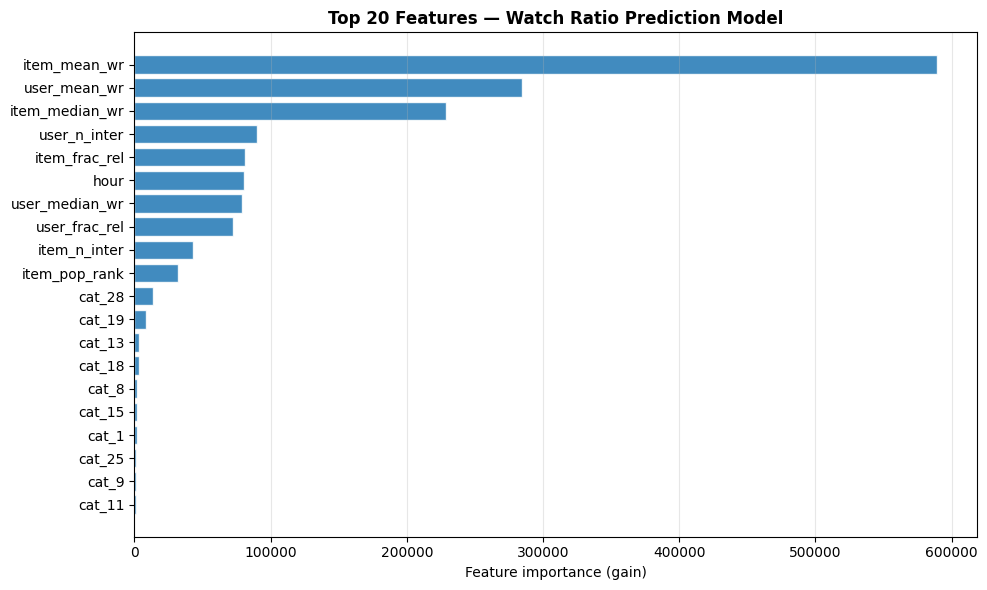

In [ ]:
if USE_LGB:
    importances = pd.Series(
        wr_model.feature_importance(importance_type="gain"),
        index=feature_cols
    ).sort_values(ascending=False)

    top_k = 20
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(importances.index[:top_k][::-1],
                   importances.values[:top_k][::-1],
                   alpha=0.85, edgecolor="white")
    ax.set_xlabel("Feature importance (gain)")
    ax.set_title(f"Top {top_k} Features — Watch Ratio Prediction Model", fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


The feature importance tells that this was unsuccesfull (metrics also). We can observe that the most importatnt features was how long the video is watched across popularity and how long this user typically engage with video. The category features sit near the bottom, consistent with what content-based filtering showed us: with only 31 categories and ~1.2 categories per video on average, the feature space is too coarse to capture meaningful individual taste.

The validation RMSE improvement over the naive baseline is also low.

## 8. Personalization Metrics

Precision and nDCG tell us how accurate the recommendations are, but they say nothing about how *different* they are across users. A model that recommends the same 20 popular videos to everyone can get high precision while being completely useless from a personalization pont of view. Nowadays personalization is an important feature, so we would like the user to feel that.

This leads to proposing new metrics:

- **Personalization** — average pairwise dissimilarity between recommendation lists across users.  0 means everyone gets the same list and  1 means no two users share a single item.
- **Coverage** — what fraction of the total item catalog appears in at least one recommendation list. Low coverage means the model is stuck in a popularity bubble and from content creators perspective that they have low chances to be ver noticed.
- **Novelty** — average popularity rank of recommended items (higher = more niche). Measures how much the model pushes users toward the long tail.
- **Intra-list diversity** — average pairwise category distance within a single user's recommendation list. Rewards lists that span multiple topics rather than flooding one category.


In [ ]:
from itertools import combinations

def personalization_score(recs_per_user, n=200):
    users = list(recs_per_user.keys())
    if len(users) < 2:
        return None
    sims = []
    pairs = list(combinations(users, 2))

    for u1, u2 in pairs:
        s1, s2 = set(recs_per_user[u1]), set(recs_per_user[u2])
        inter = len(s1 & s2)
        union = len(s1 | s2)
        sims.append(inter / union if union > 0 else 0)
    return 1 - np.mean(sims)


def catalog_coverage(recs_per_user, all_items):
    recommended = set(v for lst in recs_per_user.values() for v in lst)
    return len(recommended) / len(all_items)


def novelty_score(recs_per_user, item_popularity_rank):
    scores = []
    for lst in recs_per_user.values():
        ranks = [item_popularity_rank.get(v, len(item_popularity_rank)) for v in lst]
        scores.append(np.mean(ranks))
    return np.mean(scores)


def intra_list_diversity(recs_per_user, item_feat_df, n_sample=500):
    users = list(recs_per_user.keys())
    if len(users) > n_sample:
        users = random.sample(users, n_sample)
    diversities = []
    for uid in users:
        lst = [v for v in recs_per_user[uid] if v in item_feat_df.index]
        if len(lst) < 2:
            continue
        vecs = item_feat_df.loc[lst].values.astype(np.float32)
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        vecs = vecs / (norms + 1e-9)
        sim_matrix = vecs @ vecs.T
        n = len(lst)
        # mean off-diagonal similarity
        mean_sim = (sim_matrix.sum() - n) / (n * (n - 1))
        diversities.append(1 - mean_sim)
    return np.mean(diversities)


item_pop_rank = {v: r+1 for r, v in enumerate(item_popularity.index)}

all_catalog_items = set(big_df["video_id"].unique())



In [ ]:
model_recs = {}

print("Popularity...")
model_recs["Popularity Baseline"] = {u: popularity_recommender(u, n=20) for u in tqdm(sample_users, leave=False)}

print("User-Based CF...")
model_recs["User-Based CF"] = {u: cf_recommender(u, n=20, top_n=3) for u in tqdm(sample_users, leave=False)}

print("Content-Based...")
model_recs["Content-Based"] = {u: content_recommender(u, n=20) for u in tqdm(sample_users, leave=False)}

print("Hybrid...")
model_recs["Hybrid (CF + Content)"] = {u: hybrid_recommender(u, alpha=best_alpha, n=20) for u in tqdm(sample_users, leave=False)}

print("IPS-CF...")
model_recs["IPS-CF"] = {u: ips_cf_recommender(u, n=20) for u in tqdm(sample_users, leave=False)}

print("IPS-Content...")
model_recs["IPS-Content"] = {u: ips_content_recommender(u, n=20) for u in tqdm(sample_users, leave=False)}

print("IPS-Hybrid...")
model_recs["IPS-Hybrid"] = {u: ips_hybrid_recommender(u, alpha=best_alpha_ips, n=20) for u in tqdm(sample_users, leave=False)}

print("Done.")

print("WR Prediction...")
model_recs["WR Prediction (LGBM)"] = {u: wr_recommender(u, n=20) for u in tqdm(sample_users, leave=False)}


Popularity...


  0%|          | 0/1411 [00:00<?, ?it/s]

User-Based CF...


  0%|          | 0/1411 [00:00<?, ?it/s]

Content-Based...


...

  0%|          | 0/1411 [00:00<?, ?it/s]

IPS-Hybrid...


  0%|          | 0/1411 [00:00<?, ?it/s]

Done.
WR Prediction...


  0%|          | 0/1411 [00:00<?, ?it/s]

In [ ]:
person_results = {}

for model_name, recs in model_recs.items():
    person_results[model_name] = {
        "Personalization":      round(personalization_score(recs), 4),
        "Coverage":             round(catalog_coverage(recs, all_catalog_items), 4),
        "Novelty (mean rank)":  round(novelty_score(recs, item_pop_rank), 1),
        "Intra-list Diversity": round(intra_list_diversity(recs, item_feat_df), 4),
    }

pers_df = pd.DataFrame(person_results).T
print(pers_df.to_string())


                       Personalization  Coverage  Novelty (mean rank)  Intra-list Diversity
Popularity Baseline             0.0000    0.0019                 10.5                0.4311
User-Based CF                   0.9627    0.2187               2161.7                0.8648
Content-Based                   0.9098    0.0547               2573.2                0.1034
Hybrid (CF + Content)           0.8158    0.0490               3135.6                0.1023
IPS-CF                          0.8554    0.1037               2200.7                0.8234
IPS-Content                     0.9080    0.0630               2647.0                0.0965
IPS-Hybrid                      0.8452    0.0582               3080.5                0.0876
WR Prediction (LGBM)            0.2573    0.0058               8495.6                0.8560


## 9. Final Results



                       Precision@20  Recall@20   nDCG@20  Personalization  Coverage  Novelty (mean rank)  Intra-list Diversity
Popularity Baseline        0.795145   0.008661  0.772681           0.0000    0.0019                 10.5                0.4311
Content-Based              0.488235   0.005276  0.483991           0.9098    0.0547               2573.2                0.0927
IPS-Content                0.468958   0.005040  0.467275           0.9080    0.0630               2647.0                0.0976
IPS-Hybrid                 0.305811   0.003313  0.302933           0.8452    0.0582               3080.5                0.0953
Hybrid (CF + Content)      0.294224   0.003181  0.285244           0.8158    0.0490               3135.6                0.1003
User-Based CF              0.032247   0.000381  0.032448           0.9627    0.2187               2161.7                0.8628
IPS-CF                     0.016513   0.000200  0.019240           0.8554    0.1037               2200.7       

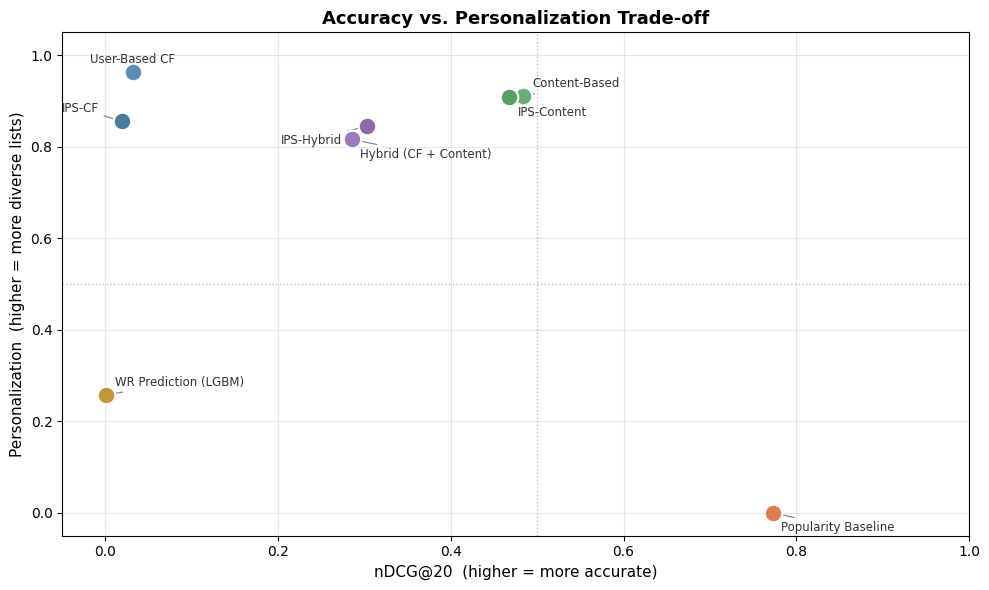

In [ ]:
acc_df = pd.DataFrame(results).T[["Precision@20", "Recall@20", "nDCG@20"]]


person_results_final = {}
for model_name, recs in model_recs.items():
    person_results_final[model_name] = {
        "Personalization":      round(personalization_score(recs), 4),
        "Coverage":             round(catalog_coverage(recs, all_catalog_items), 4),
        "Novelty (mean rank)":  round(novelty_score(recs, item_pop_rank), 1),
        "Intra-list Diversity": round(intra_list_diversity(recs, item_feat_df), 4),
    }
pers_df_final = pd.DataFrame(person_results_final).T

combined = acc_df.join(pers_df_final, how="outer").sort_values("nDCG@20", ascending=False)

print(combined.to_string())

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "Popularity Baseline":   "#E07B54",
    "User-Based CF":         "#5B8DB8",
    "Content-Based":         "#6BAE75",
    "Hybrid (CF + Content)": "#9B7BB8",
    "IPS-CF":                "#4A7BA0",
    "IPS-Content":           "#5A9E65",
    "IPS-Hybrid":            "#8A6BA8",
    "WR Prediction (LGBM)":  "#C4963A",
}

for model, row in combined.iterrows():
    x = row["nDCG@20"]
    y = row["Personalization"]
    color = colors.get(model, "#888888")
    ax.scatter(x, y, s=160, color=color, zorder=5, edgecolors="white", linewidths=1.5)
    offsets = {
        "Popularity Baseline":   ( 0.01, -0.04),
        "User-Based CF":         (-0.05,  0.02),
        "Content-Based":         ( 0.01,  0.02),
        "Hybrid (CF + Content)": ( 0.01, -0.04),
        "IPS-CF":                (-0.07,  0.02),
        "IPS-Content":           ( 0.01, -0.04),
        "IPS-Hybrid":            (-0.10, -0.04),
        "WR Prediction (LGBM)":  ( 0.01,  0.02),
    }
    dx, dy = offsets.get(model, (0.01, 0.01))
    ax.annotate(model, (x, y), xytext=(x + dx, y + dy), fontsize=8.5,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.8), color="#333333")

ax.set_xlabel("nDCG@20  (higher = more accurate)", fontsize=11)
ax.set_ylabel("Personalization  (higher = more diverse lists)", fontsize=11)
ax.set_title("Accuracy vs. Personalization Trade-off", fontweight="bold", fontsize=13)
ax.set_xlim(-0.05, 1.0)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.axhline(0.5, ls=":", color="gray", lw=1, alpha=0.5)
ax.axvline(0.5, ls=":", color="gray", lw=1, alpha=0.5)
plt.tight_layout()
plt.show()


### Discussion

The scatter plot reveals sad true - none of the models are in the top-right corner (high accuracy and high personalization).

**Popularity** is the only high-accuracy model, but using this means every user gets the exact same list. The high nDCG suggest however that this is best way for recomending items for cold-start users with high probability that they will find this relevant, so will be happy with the app.

**Content-based** is the best practical model here. It scores reasonably well on accuracy (nDCG  0.48) and has high personalization (0.91), but the cost lies in low intra-list diversity and all recommended videos tend to be from the same category. Moreover the number of categories is small, this not give a precise insigth in video content and potential outcomes.

**User-Based CF** achived extremly wrong results (nDCG 0.04). CF would likely need many more neighbors or a denser representation (matrix factorization) to work well here.

**IPS debiasing** had a mixed result as it didn't hurt content-based filtering much, but made CF slightly worse. It is worth exploring with better-calibrated propensity estimates.

**The LGBM model** reframing recommendation as regression is popular direction, but the feature space here is too shallow to beat simple heuristics as item_mean_wr ends up dominating, which is basically popularity in disguise. The interesting version of this approach would include user-item interaction history (like sequential features or matrix factorization embeddings) rather than just aggregated statistics.

## What could be improved?
First as mentioned using solution like factorization matrix would probably give better results. Second aspect is the data split. Now we have a leaking from future - the split is not based on timestamp. The honest evaluation setup for a production system would be: train on week N, validate on week N+1, deploy and measure on week N+2.

Moreover there is a question if content-based approach works reasonable in every category.

It is also worth testing how changing the WR treshold influence the models performances.


